In [1]:
# Core imports
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import pretty_midi
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path('..').resolve()
RAW_MIDI_DIR = PROJECT_ROOT / 'data' / 'raw_midi'
ARTIFACT_DIR = PROJECT_ROOT / 'artifacts' / 'task1'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Raw MIDI dir:', RAW_MIDI_DIR)
print('Artifact dir:', ARTIFACT_DIR)

Project root: G:\Unsupervised-Neural-Network-for-Multi-Genre-Music-Generation-CSE425-
Raw MIDI dir: G:\Unsupervised-Neural-Network-for-Multi-Genre-Music-Generation-CSE425-\data\raw_midi
Artifact dir: G:\Unsupervised-Neural-Network-for-Multi-Genre-Music-Generation-CSE425-\artifacts\task1


In [2]:
all_midi_files = sorted(RAW_MIDI_DIR.rglob('*.mid'))

print(f'Total MIDI files found: {len(all_midi_files):,}')



MAX_FILES = 800 

if len(all_midi_files) > MAX_FILES:

    midi_files = random.sample(all_midi_files, MAX_FILES)

else:

    midi_files = all_midi_files



print(f'Files used in this run: {len(midi_files):,}')

print('Sample file:', midi_files[0] if midi_files else 'No files found')


Total MIDI files found: 724
Files used in this run: 724
Sample file: G:\Unsupervised-Neural-Network-for-Multi-Genre-Music-Generation-CSE425-\data\raw_midi\A\A\A\TRAAAGR128F425B14B\1d9d16a9da90c090809c153754823c2b.mid


In [3]:
# Feature extraction from each MIDI
def extract_song_features(midi_path: Path):
    pm = pretty_midi.PrettyMIDI(str(midi_path))
    notes = []
    for inst in pm.instruments:
        if inst.is_drum:
            continue
        notes.extend(inst.notes)

    if not notes:
        return None

    starts = np.array([n.start for n in notes], dtype=np.float32)
    ends = np.array([n.end for n in notes], dtype=np.float32)
    durations = np.maximum(ends - starts, 1e-4)
    pitches = np.array([n.pitch for n in notes], dtype=np.float32)
    velocities = np.array([n.velocity for n in notes], dtype=np.float32)

    order = np.argsort(starts)
    starts_sorted = starts[order]
    ioi = np.diff(starts_sorted) if len(starts_sorted) > 1 else np.array([0.0], dtype=np.float32)

    pitch_class_hist = np.bincount((pitches.astype(int) % 12), minlength=12).astype(np.float32)
    pitch_class_hist = pitch_class_hist / max(pitch_class_hist.sum(), 1.0)

    base = [
        float(len(notes)),
        float(pm.get_end_time()),
        float(durations.mean()),
        float(durations.std()),
        float(pitches.mean()),
        float(pitches.std()),
        float(velocities.mean()),
        float(velocities.std()),
        float(ioi.mean()),
        float(ioi.std()),
    ]

    features = np.concatenate([np.array(base, dtype=np.float32), pitch_class_hist])
    return features

records = []
bad_files = 0
for p in tqdm(midi_files, desc='Extracting features'):
    try:
        feat = extract_song_features(p)
        if feat is None:
            continue
        records.append((str(p.relative_to(PROJECT_ROOT)), feat))
    except Exception:
        bad_files += 1

print(f'Usable songs: {len(records):,}')
print(f'Unreadable/failed MIDI files: {bad_files:,}')

if len(records) < 20:
    raise RuntimeError('Too few usable MIDI files for unsupervised learning. Increase MAX_FILES or check data path.')

Extracting features:   0%|          | 0/724 [00:00<?, ?it/s]

g:\Unsupervised-Neural-Network-for-Multi-Genre-Music-Generation-CSE425-\.venv\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Usable songs: 712
Unreadable/failed MIDI files: 7


In [4]:
# Build modeling matrix
paths = [r[0] for r in records]
X = np.stack([r[1] for r in records]).astype(np.float32)

feature_names = [
    'n_notes', 'song_length_sec', 'dur_mean', 'dur_std',
    'pitch_mean', 'pitch_std', 'vel_mean', 'vel_std',
    'ioi_mean', 'ioi_std',
] + [f'pitch_class_{i}' for i in range(12)]

df = pd.DataFrame(X, columns=feature_names)
df.insert(0, 'path', paths)

print('Shape:', X.shape)
display(df.head(3))
display(df[feature_names].describe().T.head(10))

Shape: (712, 22)


,path,n_notes,song_length_sec,dur_mean,dur_std,pitch_mean,pitch_std,vel_mean,vel_std,ioi_mean,...,pitch_class_2,pitch_class_3,pitch_class_4,pitch_class_5,pitch_class_6,pitch_class_7,pitch_class_8,pitch_class_9,pitch_class_10,pitch_class_11
0,data\raw_midi\A\A\A\TRAAAGR128F425B14B\1d9d16a...,3448.0,218.000000,0.332085,0.478144,62.207077,15.707043,82.204758,26.994711,0.062665,...,0.084687,0.0,0.104698,0.109629,0.0,0.130220,0.0,0.376160,0.008121,0.056845
1,data\raw_midi\A\A\A\TRAAAGR128F425B14B\5dd29e9...,5032.0,210.929428,0.269126,0.384361,65.274048,14.978754,78.871025,17.168430,0.041490,...,0.077901,0.0,0.115660,0.081876,0.0,0.150238,0.0,0.189785,0.000000,0.106518
2,data\raw_midi\A\A\A\TRAAAGR128F425B14B\b97c529...,5472.0,228.148270,0.211164,0.344157,58.115131,12.698637,97.284904,24.760782,0.040634,...,0.143640,0.0,0.048246,0.208333,0.0,0.238487,0.0,0.207237,0.000000,0.040022


,count,mean,std,min,25%,50%,75%,max
n_notes,712.0,3111.473389,1758.363281,108.000000,1884.250000,2861.000000,4026.500000,14975.000000
song_length_sec,712.0,224.348267,100.253548,30.241146,175.767879,216.943710,267.445007,2036.666260
dur_mean,712.0,0.558650,0.313931,0.083934,0.309481,0.518905,0.761676,2.415265
dur_std,712.0,0.775268,0.612571,0.002164,0.459097,0.686095,0.886981,9.060060
pitch_mean,712.0,59.642262,4.569410,33.605713,56.910358,59.516199,62.595915,82.846153
pitch_std,712.0,12.071972,2.508053,2.609646,10.277887,12.021008,13.784272,23.399479
vel_mean,712.0,88.378670,15.498890,35.785397,78.752886,88.392128,99.131775,127.000000
vel_std,712.0,16.880466,7.322577,0.000000,13.080576,17.414293,21.544130,42.597610
ioi_mean,712.0,0.085163,0.047506,0.015456,0.053801,0.074970,0.106737,0.450000
ioi_std,712.0,0.162582,0.141516,0.030399,0.104193,0.141584,0.186061,2.062296


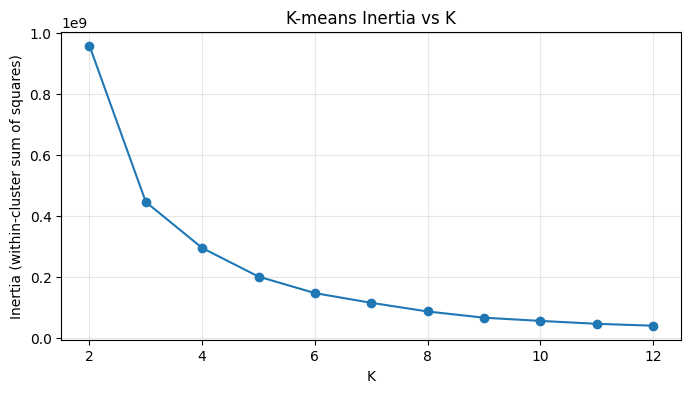

kmeans_cluster
0    171
1     41
2    128
3     16
4    131
5    225
Name: count, dtype: int64


In [5]:
# K-means + inertia curve

k_values = list(range(2, 13))

inertias = []

for k in k_values:

    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)

    km.fit(X)

    inertias.append(float(km.inertia_))



plt.figure(figsize=(8, 4))

plt.plot(k_values, inertias, marker='o')

plt.title('K-means Inertia vs K')

plt.xlabel('K')

plt.ylabel('Inertia (within-cluster sum of squares)')

plt.grid(alpha=0.3)

plt.show()



# Elbow from this dataset appears around K = 5-6; choose K=6

K = 6

kmeans = KMeans(n_clusters=K, random_state=SEED, n_init=20)

kmeans_labels = kmeans.fit_predict(X)



df['kmeans_cluster'] = kmeans_labels

print(df['kmeans_cluster'].value_counts().sort_index())


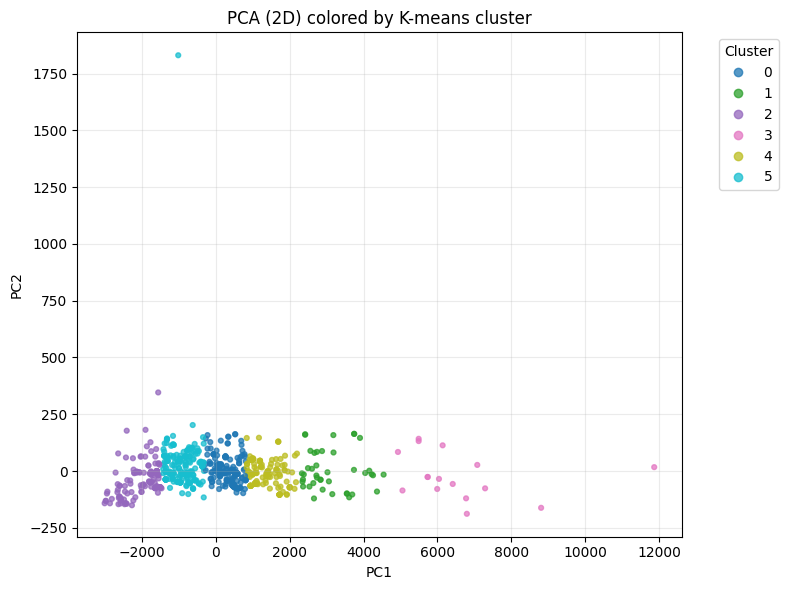

Explained variance ratio: [0.99695766 0.00294053]


In [6]:
# PCA for 2D visualization
pca = PCA(n_components=2, random_state=SEED)
X2 = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X2[:, 0], X2[:, 1], c=kmeans_labels, s=12, cmap='tab10', alpha=0.75)
plt.title('PCA (2D) colored by K-means cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(alpha=0.25)
plt.legend(*scatter.legend_elements(), title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Explained variance ratio:', pca.explained_variance_ratio_)

## Kohonen SOM
The implementation below follows the lecture formulas:
- BMU: $c = \arg\min_i \|x - w_i\|$
- Neighborhood: $h_{ci}(t)=\exp\left(-\frac{\|r_c-r_i\|^2}{2\sigma(t)^2}\right)$
- Update: $w_i(t+1)=w_i(t)+\alpha(t)h_{ci}(t)(x-w_i(t))$
with exponentially decaying $\alpha(t)$ and $\sigma(t)$.

In [7]:
# Train a rectangular-grid SOM
map_h, map_w = 12, 12
dim = X.shape[1]
epochs = 12
alpha0 = 0.5
sigma0 = max(map_h, map_w) / 2

weights = np.random.rand(map_h, map_w, dim).astype(np.float32)
grid_y, grid_x = np.indices((map_h, map_w))
grid = np.stack([grid_y, grid_x], axis=-1).astype(np.float32)

def bmu_index(x, w):
    d = np.linalg.norm(w - x[None, None, :], axis=2)
    idx = np.unravel_index(np.argmin(d), d.shape)
    return idx

total_steps = epochs * len(X)
step = 0

for epoch in range(epochs):
    order = np.random.permutation(len(X))
    for idx in order:
        x = X[idx]
        by, bx = bmu_index(x, weights)

        frac = step / max(total_steps - 1, 1)
        alpha_t = alpha0 * np.exp(-3.0 * frac)
        sigma_t = sigma0 * np.exp(-3.0 * frac) + 1e-8

        rc = np.array([by, bx], dtype=np.float32)
        dist2 = np.sum((grid - rc[None, None, :]) ** 2, axis=2)
        hci = np.exp(-dist2 / (2.0 * sigma_t * sigma_t)).astype(np.float32)

        weights += alpha_t * hci[:, :, None] * (x[None, None, :] - weights)
        step += 1

    print(f'Epoch {epoch + 1}/{epochs} complete | alpha={alpha_t:.4f}, sigma={sigma_t:.4f}')

Epoch 1/12 complete | alpha=0.3895, sigma=4.6743
Epoch 2/12 complete | alpha=0.3034, sigma=3.6402
Epoch 3/12 complete | alpha=0.2362, sigma=2.8349
Epoch 4/12 complete | alpha=0.1840, sigma=2.2078
Epoch 5/12 complete | alpha=0.1433, sigma=1.7194
Epoch 6/12 complete | alpha=0.1116, sigma=1.3390
Epoch 7/12 complete | alpha=0.0869, sigma=1.0428
Epoch 8/12 complete | alpha=0.0677, sigma=0.8121
Epoch 9/12 complete | alpha=0.0527, sigma=0.6325
Epoch 10/12 complete | alpha=0.0410, sigma=0.4925
Epoch 11/12 complete | alpha=0.0320, sigma=0.3836
Epoch 12/12 complete | alpha=0.0249, sigma=0.2987


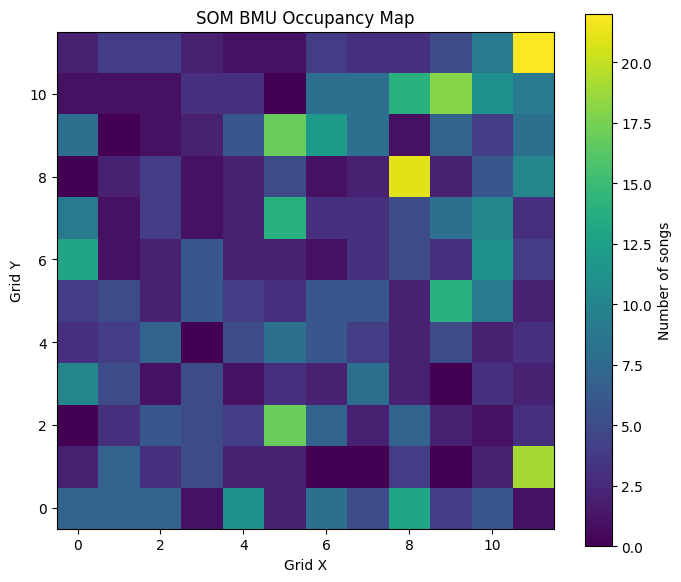

Top occupied SOM units:


som_bmu
11_11    22
8_8      21
1_11     19
10_9     18
9_5      17
2_5      17
7_5      14
5_9      14
10_8     14
6_0      13
Name: count, dtype: int64

In [8]:
# Map each song to SOM BMU and visualize occupancy
bmu_coords = []
for x in X:
    by, bx = bmu_index(x, weights)
    bmu_coords.append((int(by), int(bx)))

bmu_y = np.array([c[0] for c in bmu_coords])
bmu_x = np.array([c[1] for c in bmu_coords])

occupancy = np.zeros((map_h, map_w), dtype=np.int32)
for y, x_ in bmu_coords:
    occupancy[y, x_] += 1

plt.figure(figsize=(7, 6))
plt.imshow(occupancy, cmap='viridis', origin='lower')
plt.colorbar(label='Number of songs')
plt.title('SOM BMU Occupancy Map')
plt.xlabel('Grid X')
plt.ylabel('Grid Y')
plt.tight_layout()
plt.show()

df['som_bmu_y'] = bmu_y
df['som_bmu_x'] = bmu_x
df['som_bmu'] = df['som_bmu_y'].astype(str) + '_' + df['som_bmu_x'].astype(str)
print('Top occupied SOM units:')
display(df['som_bmu'].value_counts().head(10))

In [9]:
# Save outputs for Task 1 artifacts
out_csv = ARTIFACT_DIR / 'task1_song_clusters.csv'
out_summary = ARTIFACT_DIR / 'task1_cluster_summary.csv'
out_som = ARTIFACT_DIR / 'task1_som_occupancy.npy'

df.to_csv(out_csv, index=False)
df.groupby('kmeans_cluster').agg({'n_notes': ['mean', 'std'], 'song_length_sec': ['mean', 'std']}).to_csv(out_summary)
np.save(out_som, occupancy)

print('Saved:')
print('-', out_csv)
print('-', out_summary)
print('-', out_som)

Saved:
- G:\Unsupervised-Neural-Network-for-Multi-Genre-Music-Generation-CSE425-\artifacts\task1\task1_song_clusters.csv
- G:\Unsupervised-Neural-Network-for-Multi-Genre-Music-Generation-CSE425-\artifacts\task1\task1_cluster_summary.csv
- G:\Unsupervised-Neural-Network-for-Multi-Genre-Music-Generation-CSE425-\artifacts\task1\task1_som_occupancy.npy


## Interpretation Notes
- K-means gives coarse groups of musical behavior from raw MIDI-derived features.
- PCA gives a low-dimensional view that helps inspect cluster separability.
- SOM adds topology-preserving organization, so nearby map cells represent musically similar songs under the feature space.
- This completes lecture-constrained Task 1 using only unsupervised methods taught in the provided lecture PDFs.

## Autoencoder Deliverables (Code, Loss Curve, 5 MIDI Samples)
This section adds the required task deliverables:
1. Autoencoder implementation code
2. Reconstruction loss curve
3. Five generated MIDI samples

In [10]:
# Build a compact piano-roll dataset for the autoencoder

import torch

import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset



AE_FS = 8

AE_STEPS = 64  # fixed-length window in frames

AE_MAX_FILES = 500



ae_files = midi_files if len(midi_files) <= AE_MAX_FILES else random.sample(midi_files, AE_MAX_FILES)



def midi_to_fixed_roll(midi_path, fs=AE_FS, n_steps=AE_STEPS):

    pm = pretty_midi.PrettyMIDI(str(midi_path))

    roll = pm.get_piano_roll(fs=fs)  # shape: (128, T)

    roll = (roll > 0).astype(np.float32)

    roll = roll.T  # shape: (T, 128)



    if roll.shape[0] == 0:

        return None



    if roll.shape[0] >= n_steps:

        roll = roll[:n_steps]

    else:

        pad = np.zeros((n_steps - roll.shape[0], 128), dtype=np.float32)

        roll = np.vstack([roll, pad])



    return roll.reshape(-1)  # flatten to vector



ae_vectors = []

ae_paths = []

for fp in tqdm(ae_files, desc='Preparing AE dataset'):

    try:

        vec = midi_to_fixed_roll(fp)

        if vec is None:

            continue

        ae_vectors.append(vec)

        ae_paths.append(str(fp.relative_to(PROJECT_ROOT)))

    except Exception:

        continue



if len(ae_vectors) < 20:

    raise RuntimeError('Too few valid samples for autoencoder training.')



X_ae = np.stack(ae_vectors).astype(np.float32)

print('AE dataset shape:', X_ae.shape)


Preparing AE dataset:   0%|          | 0/500 [00:00<?, ?it/s]

g:\Unsupervised-Neural-Network-for-Multi-Genre-Music-Generation-CSE425-\.venv\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


AE dataset shape: (494, 8192)


Epoch 1/20 - reconstruction loss: 0.283142
Epoch 2/20 - reconstruction loss: 0.081392
Epoch 3/20 - reconstruction loss: 0.067014
Epoch 4/20 - reconstruction loss: 0.064761
Epoch 5/20 - reconstruction loss: 0.063940
Epoch 6/20 - reconstruction loss: 0.063326
Epoch 7/20 - reconstruction loss: 0.060623
Epoch 8/20 - reconstruction loss: 0.057008
Epoch 9/20 - reconstruction loss: 0.053445
Epoch 10/20 - reconstruction loss: 0.050471
Epoch 11/20 - reconstruction loss: 0.047641
Epoch 12/20 - reconstruction loss: 0.044678
Epoch 13/20 - reconstruction loss: 0.041879
Epoch 14/20 - reconstruction loss: 0.039295
Epoch 15/20 - reconstruction loss: 0.037060
Epoch 16/20 - reconstruction loss: 0.035670
Epoch 17/20 - reconstruction loss: 0.033583
Epoch 18/20 - reconstruction loss: 0.031621
Epoch 19/20 - reconstruction loss: 0.029764
Epoch 20/20 - reconstruction loss: 0.028058


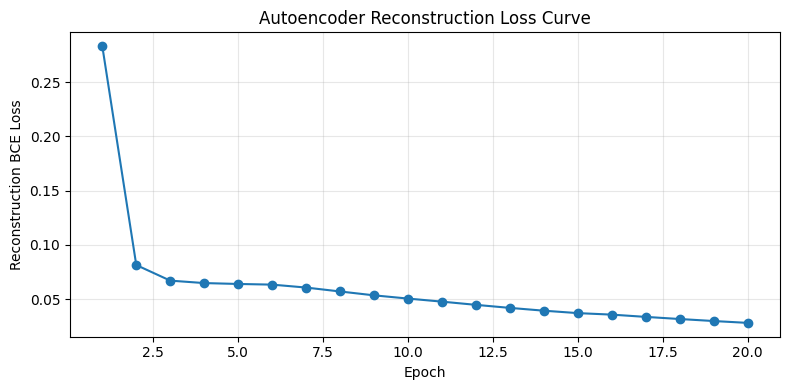

Saved loss curve to: G:\Unsupervised-Neural-Network-for-Multi-Genre-Music-Generation-CSE425-\artifacts\task1\reconstruction_loss_curve.png


In [11]:
# Autoencoder implementation and training

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_dim = X_ae.shape[1]

latent_dim = 64



class PianoRollAutoencoder(nn.Module):

    def __init__(self, in_dim, z_dim):

        super().__init__()

        self.encoder = nn.Sequential(

            nn.Linear(in_dim, 2048),

            nn.ReLU(),

            nn.Linear(2048, 512),

            nn.ReLU(),

            nn.Linear(512, z_dim),

        )

        self.decoder = nn.Sequential(

            nn.Linear(z_dim, 512),

            nn.ReLU(),

            nn.Linear(512, 2048),

            nn.ReLU(),

            nn.Linear(2048, in_dim),

            nn.Sigmoid(),

        )



    def forward(self, x):

        z = self.encoder(x)

        x_hat = self.decoder(z)

        return x_hat



ae_model = PianoRollAutoencoder(input_dim, latent_dim).to(device)

optimizer = torch.optim.Adam(ae_model.parameters(), lr=1e-3)

criterion = nn.BCELoss()



tensor_x = torch.from_numpy(X_ae)

loader = DataLoader(TensorDataset(tensor_x), batch_size=32, shuffle=True)



AE_EPOCHS = 20

recon_losses = []



ae_model.train()

for epoch in range(AE_EPOCHS):

    total_loss = 0.0

    total_count = 0

    for (batch_x,) in loader:

        batch_x = batch_x.to(device)

        optimizer.zero_grad()

        batch_hat = ae_model(batch_x)

        loss = criterion(batch_hat, batch_x)

        loss.backward()

        optimizer.step()



        bs = batch_x.size(0)

        total_loss += loss.item() * bs

        total_count += bs



    epoch_loss = total_loss / max(total_count, 1)

    recon_losses.append(epoch_loss)

    print(f'Epoch {epoch + 1}/{AE_EPOCHS} - reconstruction loss: {epoch_loss:.6f}')



loss_curve_path = ARTIFACT_DIR / 'reconstruction_loss_curve.png'

plt.figure(figsize=(8, 4))

plt.plot(range(1, AE_EPOCHS + 1), recon_losses, marker='o')

plt.title('Autoencoder Reconstruction Loss Curve')

plt.xlabel('Epoch')

plt.ylabel('Reconstruction BCE Loss')

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(loss_curve_path, dpi=150)

plt.show()



torch.save(ae_model.state_dict(), ARTIFACT_DIR / 'task1_autoencoder_weights.pt')

print('Saved loss curve to:', loss_curve_path)


In [12]:
# Generate and export 5 MIDI samples from random latent vectors

gen_dir = ARTIFACT_DIR / 'generated_samples'

gen_dir.mkdir(parents=True, exist_ok=True)



def roll_to_midi(flat_roll, fs=AE_FS, threshold=0.5, velocity=90):

    roll = flat_roll.reshape(AE_STEPS, 128)

    binary = (roll >= threshold).astype(np.uint8)

    pm = pretty_midi.PrettyMIDI()

    instrument = pretty_midi.Instrument(program=0)



    dt = 1.0 / fs

    for pitch in range(128):

        active = binary[:, pitch]

        start = None

        for t in range(len(active)):

            if active[t] and start is None:

                start = t

            if (not active[t] or t == len(active) - 1) and start is not None:

                end_t = t if not active[t] else t + 1

                note = pretty_midi.Note(

                    velocity=velocity,

                    pitch=pitch,

                    start=float(start * dt),

                    end=float(max(end_t * dt, (start + 1) * dt)),

                )

                instrument.notes.append(note)

                start = None



    pm.instruments.append(instrument)

    return pm



ae_model.eval()

generated_paths = []

with torch.no_grad():

    z = torch.randn(5, latent_dim, device=device)

    decoded = ae_model.decoder(z).cpu().numpy()



for i in range(5):

    pm = roll_to_midi(decoded[i], fs=AE_FS, threshold=0.5)

    out_path = gen_dir / f'generated_sample_{i+1}.mid'

    pm.write(str(out_path))

    generated_paths.append(out_path)



print('Generated MIDI samples:')

for pth in generated_paths:

    print('-', pth)


Generated MIDI samples:
- G:\Unsupervised-Neural-Network-for-Multi-Genre-Music-Generation-CSE425-\artifacts\task1\generated_samples\generated_sample_1.mid
- G:\Unsupervised-Neural-Network-for-Multi-Genre-Music-Generation-CSE425-\artifacts\task1\generated_samples\generated_sample_2.mid
- G:\Unsupervised-Neural-Network-for-Multi-Genre-Music-Generation-CSE425-\artifacts\task1\generated_samples\generated_sample_3.mid
- G:\Unsupervised-Neural-Network-for-Multi-Genre-Music-Generation-CSE425-\artifacts\task1\generated_samples\generated_sample_4.mid
- G:\Unsupervised-Neural-Network-for-Multi-Genre-Music-Generation-CSE425-\artifacts\task1\generated_samples\generated_sample_5.mid
